In [ ]:
"""
BUSINESS PROBLEM

An e-commerce company is experiencing low checkout conversion rates despite high user traffic,
resulting in significant potential revenue loss.

To address this, the product team introduced a redesigned checkout experience (Variant B)
to reduce friction and improve user conversion.

OBJECTIVE

Evaluate whether Variant B leads to a statistically significant improvement in:

- Conversion Rate
- Revenue per User

using A/B testing and statistical analysis, and provide a data-driven recommendation
on whether to deploy the new checkout experience.
"""

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\abhis\ab_testing_dataset.csv")
df.head

<bound method NDFrame.head of        user_id group user_type            timestamp  conversion     revenue  \
0            1     A       New  2024-01-01 00:00:00           0    0.000000   
1            2     B       New  2024-01-01 00:01:00           0    0.000000   
2            3     A       New  2024-01-01 00:02:00           1  399.446066   
3            4     A       New  2024-01-01 00:03:00           0    0.000000   
4            5     A       New  2024-01-01 00:04:00           0    0.000000   
...        ...   ...       ...                  ...         ...         ...   
19995    19996     A    Repeat  2024-01-14 21:15:00           0    0.000000   
19996    19997     A    Repeat  2024-01-14 21:16:00           0    0.000000   
19997    19998     A       New  2024-01-14 21:17:00           0    0.000000   
19998    19999     B       New  2024-01-14 21:18:00           0    0.000000   
19999    20000     A       New  2024-01-14 21:19:00           0    0.000000   

       add_to_cart  


In [2]:
"""
CONVERSION ANALYSIS

Calculate conversion rates for Variant A and Variant B
to understand baseline performance differences.
"""

conversion_rates = df.groupby("group")["conversion"].mean()
conversion_counts = df.groupby("group")["conversion"].sum()
total_users = df.groupby("group")["user_id"].count()

print("Conversion Rates:\n", conversion_rates)
print("\nConversions:\n", conversion_counts)
print("\nTotal Users:\n", total_users)

Conversion Rates:
 group
A    0.098802
B    0.123146
Name: conversion, dtype: float64

Conversions:
 group
A     990
B    1229
Name: conversion, dtype: int64

Total Users:
 group
A    10020
B     9980
Name: user_id, dtype: int64


In [ ]:
"""
INSIGHT:

Variant B shows a higher conversion rate (~12.3%) compared to Variant A (~9.9%),
indicating a strong improvement in user purchase behavior.

This suggests that the redesigned checkout experience may be more effective,
but statistical testing is required to confirm if the difference is significant.
"""

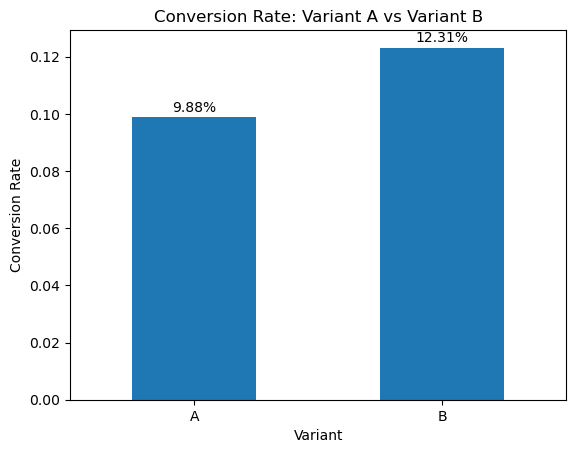

In [7]:
plt.figure()

ax = conversion_rates.plot(kind='bar')

# Add value labels
for i, v in enumerate(conversion_rates):
    ax.text(i, v + 0.002, f"{v:.2%}", ha='center')

plt.title("Conversion Rate: Variant A vs Variant B")
plt.xlabel("Variant")
plt.ylabel("Conversion Rate")

plt.xticks(rotation=0)
plt.show()

In [ ]:
"""
INSIGHT:

Variant B shows a clear improvement in conversion rate compared to Variant A,
with an uplift of ~2.4 percentage points.

This visual confirms a strong performance difference,
which will be validated using statistical testing in the next step.
"""

In [ ]:
"""
HYPOTHESIS

H0 (Null Hypothesis):
There is no significant difference in conversion rates between Variant A and Variant B

H1 (Alternative Hypothesis):
Variant B has a higher conversion rate than Variant A
"""

In [8]:
from statsmodels.stats.proportion import proportions_ztest

success = conversion_counts.values
nobs = total_users.values

z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)


Z-statistic: -5.480844689800401
P-value: 4.2329995468478476e-08


In [ ]:
"""
STATISTICAL CONCLUSION

- P-value is significantly less than 0.05, indicating strong statistical evidence
- We reject the null hypothesis (H0)

 Interpretation:
Variant B performs significantly better than Variant A in terms of conversion rate

This confirms that the observed improvement is not due to random chance
"""

In [ ]:
"""
SEGMENT ANALYSIS

Analyze conversion rates across user segments (New vs Repeat users)
to understand where the improvement is most significant.
"""

In [10]:
segment_conversion = df.groupby(["group", "user_type"])["conversion"].mean().unstack()

segment_counts = df.groupby(["group", "user_type"])["conversion"].sum().unstack()

segment_users = df.groupby(["group", "user_type"])["user_id"].count().unstack()

print("Conversion Rate:\n", segment_conversion)
print("\nConversions:\n", segment_counts)
print("\nUsers:\n", segment_users)

Conversion Rate:
 user_type       New    Repeat
group                        
A          0.103926  0.086899
B          0.121251  0.127532

Conversions:
 user_type  New  Repeat
group                 
A          728     262
B          845     384

Users:
 user_type   New  Repeat
group                  
A          7005    3015
B          6969    3011


In [ ]:
"""
INSIGHT:

Variant B improves conversion rates across both user segments.

- New Users: ~10.4% → ~12.1%
- Repeat Users: ~8.7% → ~12.8%

The uplift is significantly higher among repeat users,
indicating that the redesigned checkout experience is particularly effective
for returning customers.

This suggests strong potential for improving customer retention and lifetime value.
"""

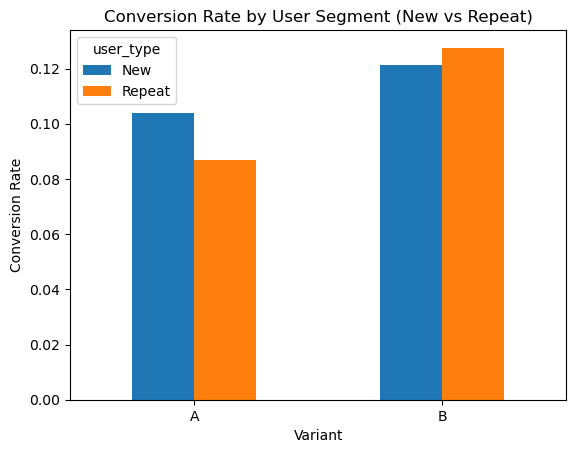

In [11]:
segment_conversion.plot(kind='bar')

plt.title("Conversion Rate by User Segment (New vs Repeat)")
plt.ylabel("Conversion Rate")
plt.xlabel("Variant")

plt.xticks(rotation=0)
plt.show()

In [ ]:
"""
REVENUE ANALYSIS

Evaluate the impact of Variant B on revenue per user and total revenue.
"""

In [13]:
revenue_analysis = df.groupby("group")["revenue"].mean()
total_revenue = df.groupby("group")["revenue"].sum()

print("Revenue per User:\n", revenue_analysis)
print("\nTotal Revenue:\n", total_revenue)

Revenue per User:
 group
A    59.578696
B    74.390163
Name: revenue, dtype: float64

Total Revenue:
 group
A    596978.538090
B    742413.826711
Name: revenue, dtype: float64


In [ ]:
"""
INSIGHT:

Variant B significantly increases revenue performance:

- Revenue per User: ₹59.6 → ₹74.4 (~25% increase)
- Total Revenue: ₹5.97L → ₹7.42L

This confirms that the improvement in conversion rate directly translates
into higher revenue generation.

The redesigned checkout experience not only drives more conversions
but also increases overall business value.
"""

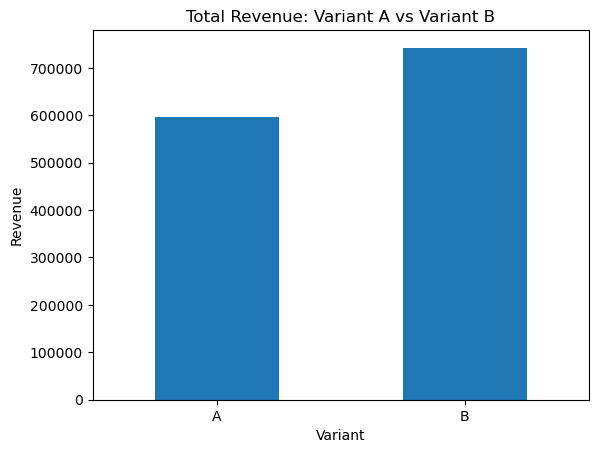

In [14]:
total_revenue.plot(kind='bar')

plt.title("Total Revenue: Variant A vs Variant B")
plt.ylabel("Revenue")
plt.xlabel("Variant")

plt.xticks(rotation=0)
plt.show()

In [ ]:
"""
TREND ANALYSIS

Analyze conversion rate trends over time to validate whether
Variant B's performance is consistent and stable.
"""

<Figure size 1500x200 with 0 Axes>

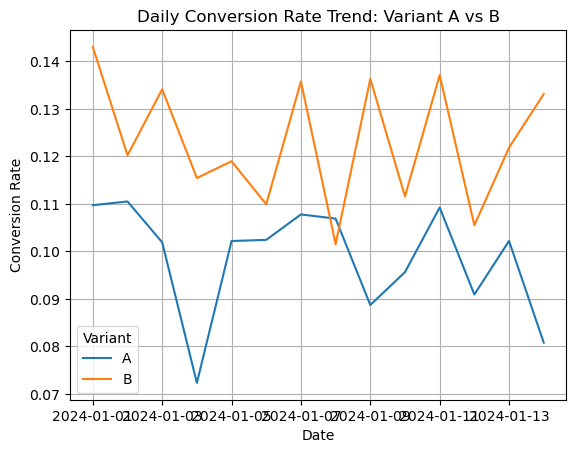

In [16]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

daily_conversion = df.groupby(['date', 'group'])['conversion'].mean().unstack()

plt.figure(figsize=(15,2))

daily_conversion.plot()

plt.title("Daily Conversion Rate Trend: Variant A vs B")
plt.xlabel("Date")
plt.ylabel("Conversion Rate")

plt.legend(title="Variant")
plt.grid(True)

plt.show()

In [ ]:
"""
INSIGHT:

Variant B consistently outperforms Variant A across the entire time period.

The conversion rate for Variant B remains higher on most days,
with no signs of instability or sharp drops.

This indicates that the observed improvement is stable, reliable,
and not driven by short-term fluctuations or anomalies.
"""

In [17]:
n = len(df)
conversion_diff = conversion_rates["B"] - conversion_rates["A"]

avg_revenue = df["revenue"].mean()

estimated_gain = conversion_diff * n * avg_revenue

print(f"Estimated Revenue Uplift: ₹{estimated_gain:,.0f}")

Estimated Revenue Uplift: ₹32,606


In [ ]:
"""
BUSINESS IMPACT

The improvement in conversion rate is estimated to generate an additional
₹32,600+ in revenue during the test period.

This demonstrates a clear and measurable financial benefit of the redesigned
checkout experience.

The uplift in both conversion rate and revenue per user confirms that Variant B
not only drives more conversions but also increases overall business value.
"""

In [18]:

# FINAL DECISION & BUSINESS IMPACT


alpha = 0.05

print("\n=== STATISTICAL RESULTS ===")
print(f"P-value: {p_value}")
print(f"Conversion A: {conversion_rates['A']:.4f}")
print(f"Conversion B: {conversion_rates['B']:.4f}")
print(f"Estimated Revenue Uplift: ₹{estimated_gain:.2f}")

# Final Decision Logic
if p_value < alpha and conversion_rates["B"] > conversion_rates["A"]:
    decision = "Deploy Variant B"
else:
    decision = "Continue Testing"

print("\n=== FINAL DECISION ===")
print(decision)


=== STATISTICAL RESULTS ===
P-value: 4.2329995468478476e-08
Conversion A: 0.0988
Conversion B: 0.1231
Estimated Revenue Uplift: ₹32606.03

=== FINAL DECISION ===
Deploy Variant B


In [ ]:
"""
FINAL DECISION & BUSINESS IMPACT

The A/B test results confirm that Variant B significantly outperforms Variant A.

- Conversion rate improved from ~9.9% to ~12.3% (+2.4%)
- Results are statistically significant (p < 0.05)
- Revenue per user and total revenue increased
- Repeat users contributed strongly to the uplift

  Estimated Impact:
- Immediate gain: ~₹32K additional revenue
- Scalable opportunity: Significant revenue growth at higher traffic

  Key Insight:
The improvement is consistent across time and user segments,
indicating a stable and reliable uplift rather than random variation.

  FINAL RECOMMENDATION:
Deploy Variant B to improve conversion, revenue, and overall business performance.
"""